# Cases 1 and 2: static latent estimator debugger
The optimizer lives in `causal_opt.methods.static_latent`; this notebook only simulates, fits, evaluates, and plots diagnostics.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from causal_opt.simulation import simulate_static_sem, simulate_static_latent_sem
from causal_opt.methods.static_latent import fit_static_latent
from causal_opt.baselines.notears import fit_notears
from causal_opt.evaluation.dag_metrics import dag_metrics
from causal_opt.evaluation.latent_metrics import latent_metrics

## Case 1: same-data comparison with official NOTEARS

official: {'fdr': 0.0, 'tpr': 1.0, 'recall': 1.0, 'fpr': 0.0, 'precision': 1.0, 'f1': 1.0, 'shd': 0, 'nnz': 10, 'weight_rmse': 0.05035381853825211, 'h': 0.0}
ours: {'fdr': 0.0, 'tpr': 1.0, 'recall': 1.0, 'fpr': 0.0, 'precision': 1.0, 'f1': 1.0, 'shd': 0, 'nnz': 10, 'weight_rmse': 0.050314292217066535, 'h': 0.0}


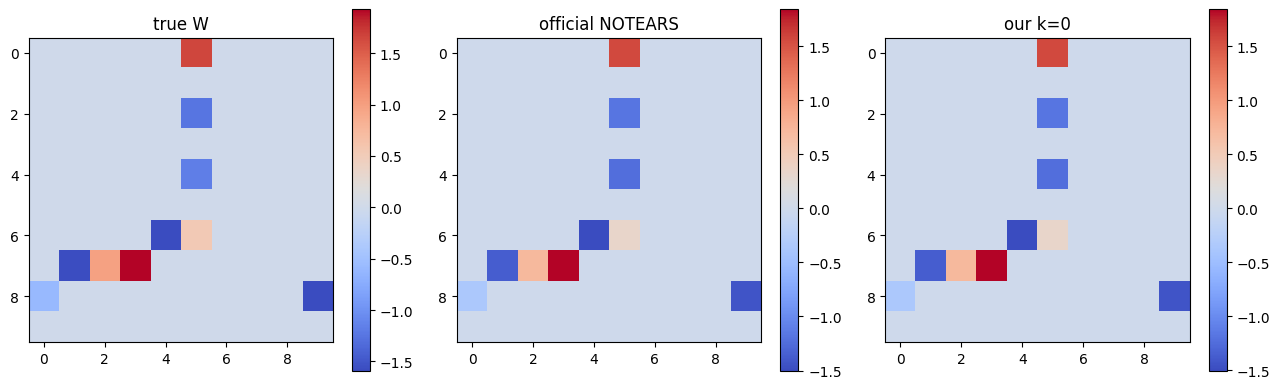

In [2]:
case1 = simulate_static_sem(n=1000, d=10, s0=10, seed=1)
official = fit_notears(case1.X, lambda1=0.1, loss_type='l2')
case1_est = fit_static_latent(case1.X, k=0, lambda_w=0.1)
print('official:', dag_metrics(case1.W_true, official.W0, threshold=0))
print('ours:', dag_metrics(case1.W_true, case1_est.W0, threshold=0))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, matrix, title in zip(axes, [case1.W_true, official.W0, case1_est.W0], ['true W', 'official NOTEARS', 'our k=0']):
    image = ax.imshow(matrix, cmap='coolwarm'); ax.set_title(title); fig.colorbar(image, ax=ax)
plt.tight_layout()

## Case 2: joint DAG and latent fit
The parameters below are explicitly an implementation/debug choice, not a benchmark-selected setting.

In [3]:
case2 = simulate_static_latent_sem(n=2000, d_obs=10, s0=10, k=2, seed=1, min_latent_children=2)
case2_est = fit_static_latent(case2.X, k=2, lambda_w=0.1, lambda_latent=0.02, random_state=1)
print('graph:', dag_metrics(case2.W_true, case2_est.W0, threshold=0))
print('latent:', latent_metrics(case2.C_true, case2_est.C, case2.L_true, case2_est.L))
print({key: case2_est.diagnostics[key] for key in ['h_raw','fit_loss','Z_fro_norm','L_fro_norm','C_fro_norm','effective_rank_C','optimizer_success']})

graph: {'fdr': 0.1111111111111111, 'tpr': 0.8, 'recall': 0.8, 'fpr': 0.0125, 'precision': 0.8888888888888888, 'f1': 0.8421052631578948, 'shd': 3, 'nnz': 9, 'weight_rmse': 0.134474262458432, 'h': 0.0}
latent: {'c_reconstruction_error': 0.6918937681226652, 'effective_rank': 2, 'loading_subspace_error': 0.6084335888831769}
{'h_raw': 7.905734733526515e-09, 'fit_loss': 5.557574173796393, 'Z_fro_norm': 9.575094662013894, 'L_fro_norm': 9.574415061925615, 'C_fro_norm': 65.1805312736696, 'effective_rank_C': 2, 'optimizer_success': True}


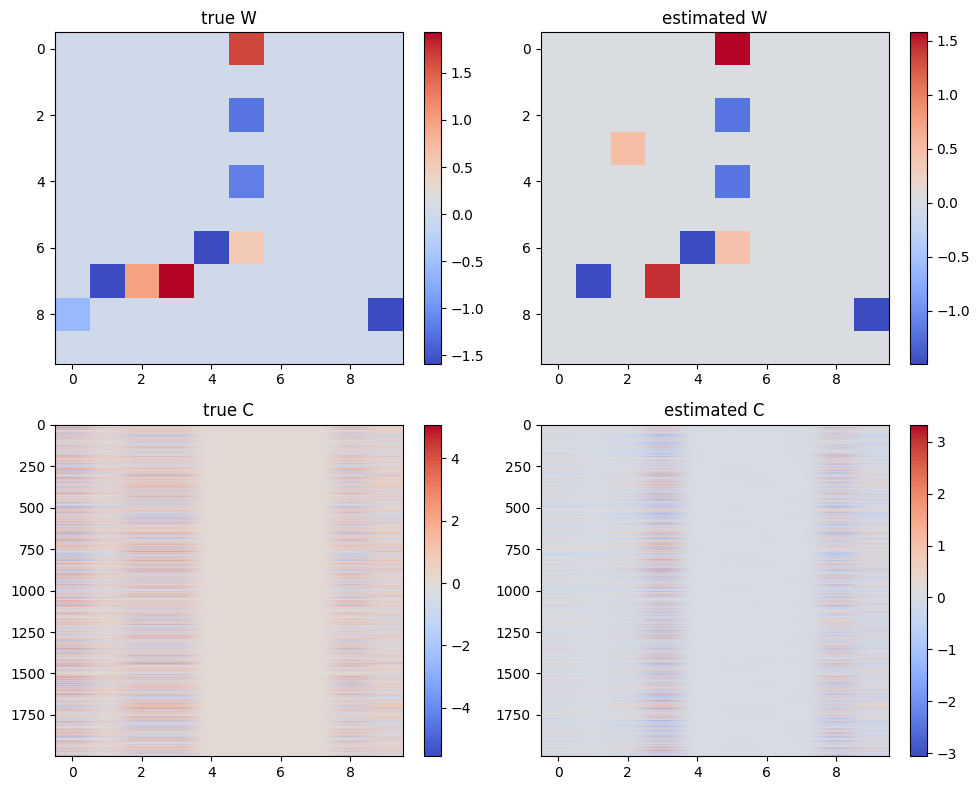

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, matrix, title in zip(axes.ravel(), [case2.W_true, case2_est.W0, case2.C_true, case2_est.C], ['true W', 'estimated W', 'true C', 'estimated C']):
    image = ax.imshow(matrix, aspect='auto', cmap='coolwarm'); ax.set_title(title); fig.colorbar(image, ax=ax)
plt.tight_layout()

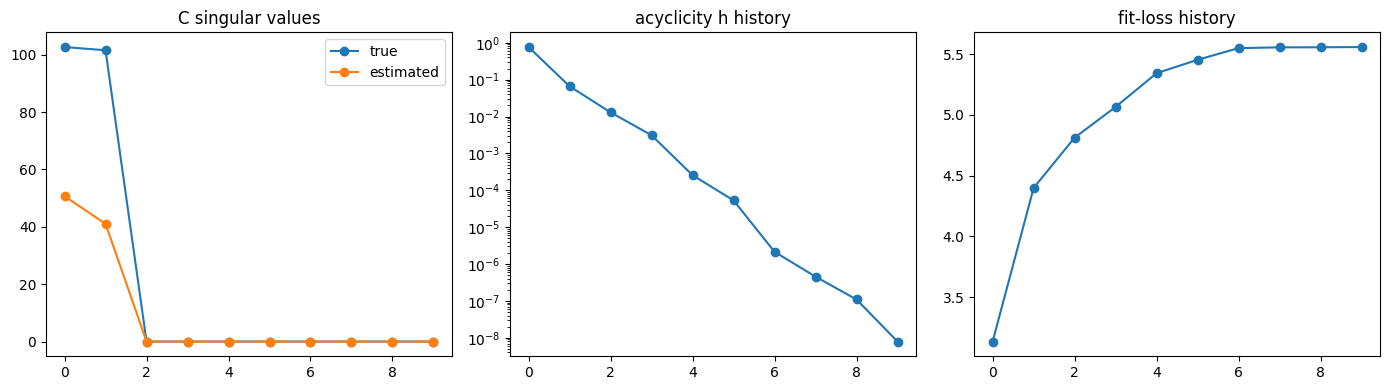

In [ ]:
s_true = np.linalg.svd(case2.C_true, compute_uv=False)
s_est = np.linalg.svd(case2_est.C, compute_uv=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(s_true, 'o-', label='true'); axes[0].plot(s_est, 'o-', label='estimated'); axes[0].set_title('C singular values'); axes[0].legend()
history = case2_est.diagnostics['history']
axes[1].semilogy([max(row['h'], 1e-18) for row in history], 'o-'); axes[1].set_title('acyclicity h history')
axes[2].plot([row['fit_loss'] for row in history], 'o-'); axes[2].set_title('fit-loss history')
plt.tight_layout() # Fit-loss rising indicates we are finding a better DAG (decreasing h(W))